# Skin Cancer MNIST: HAM10000 — Improved
### Medical Image Classification with CNN Improved
**Improvements over baseline:**
1. Transfer Learning with ResNet18 (replaces training from scratch)
2. Focal Loss (replaces standard cross-entropy to handle class imbalance)
3. Grad-CAM Visualisation + Per-Class Metrics (explainability)
4. Domain-Safe Data Augmentation (flips, rotation, colour jitter)

### 1. Importing Essential Libraries

In [36]:
import kagglehub
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, recall_score
)

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


### 2. Configuration

In [37]:
# ── Download Dataset via KaggleHub ────────────────────────────────────────
# kagglehub downloads the dataset and returns the local path automatically
BASE_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", BASE_DIR)

# ── Derived Paths ──────────────────────────────────────────────────────────
METADATA_CSV = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')
MODEL_SAVE   = 'Models/resnet18_improved.pth'
os.makedirs('Models', exist_ok=True)
os.makedirs('Photos', exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────
IMG_SIZE    = 224        # ResNet18 expects 224x224
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-4
NUM_CLASSES = 7

# Focal loss parameters
FOCAL_GAMMA = 2.0        # focusing parameter
FOCAL_ALPHA = None       # set to a tensor of per-class weights if desired

# ── Label maps ────────────────────────────────────────────────────────────
LESION_TYPE = {
    'nv':    'Melanocytic nevi',
    'mel':   'Melanoma',
    'bkl':   'Benign keratosis-like lesions',
    'bcc':   'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc':  'Vascular lesions',
    'df':    'Dermatofibroma'
}
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'mel', 'vasc']  # alphabetical

Dataset path: /Users/alice/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


### 3. Load & Prepare Metadata

In [38]:
# Build image-id → path dictionary
imageid_path = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(BASE_DIR, '**', '*.jpg'), recursive=True)
}

skin_df = pd.read_csv(METADATA_CSV)
skin_df['path']          = skin_df['image_id'].map(imageid_path.get)
skin_df['cell_type']     = skin_df['dx'].map(LESION_TYPE.get)
skin_df['cell_type_idx'] = pd.Categorical(skin_df['cell_type']).codes

# Remove duplicates & fill missing age
skin_df = skin_df.drop_duplicates(subset='lesion_id')
skin_df['age'].fillna(skin_df['age'].mean(), inplace=True)

print(f'Dataset size after dedup: {len(skin_df)}')
print(skin_df['dx'].value_counts())

Dataset size after dedup: 7470
dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: count, dtype: int64


### 4. Exploratory Data Analysis

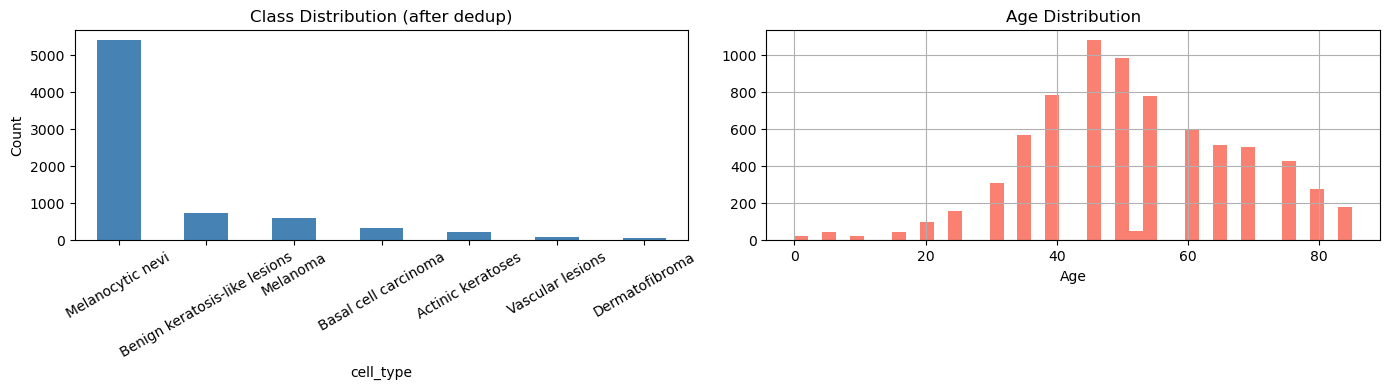


--- Class Imbalance Summary ---
cell_type
Melanocytic nevi                 5403
Benign keratosis-like lesions     727
Melanoma                          614
Basal cell carcinoma              327
Actinic keratoses                 228
Vascular lesions                   98
Dermatofibroma                     73
Name: count, dtype: int64


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
counts = skin_df['cell_type'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution (after dedup)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Age distribution
skin_df['age'].hist(bins=40, ax=axes[1], color='salmon')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.savefig('Photos/eda.png', dpi=150)
plt.show()
print('\n--- Class Imbalance Summary ---')
print(counts)

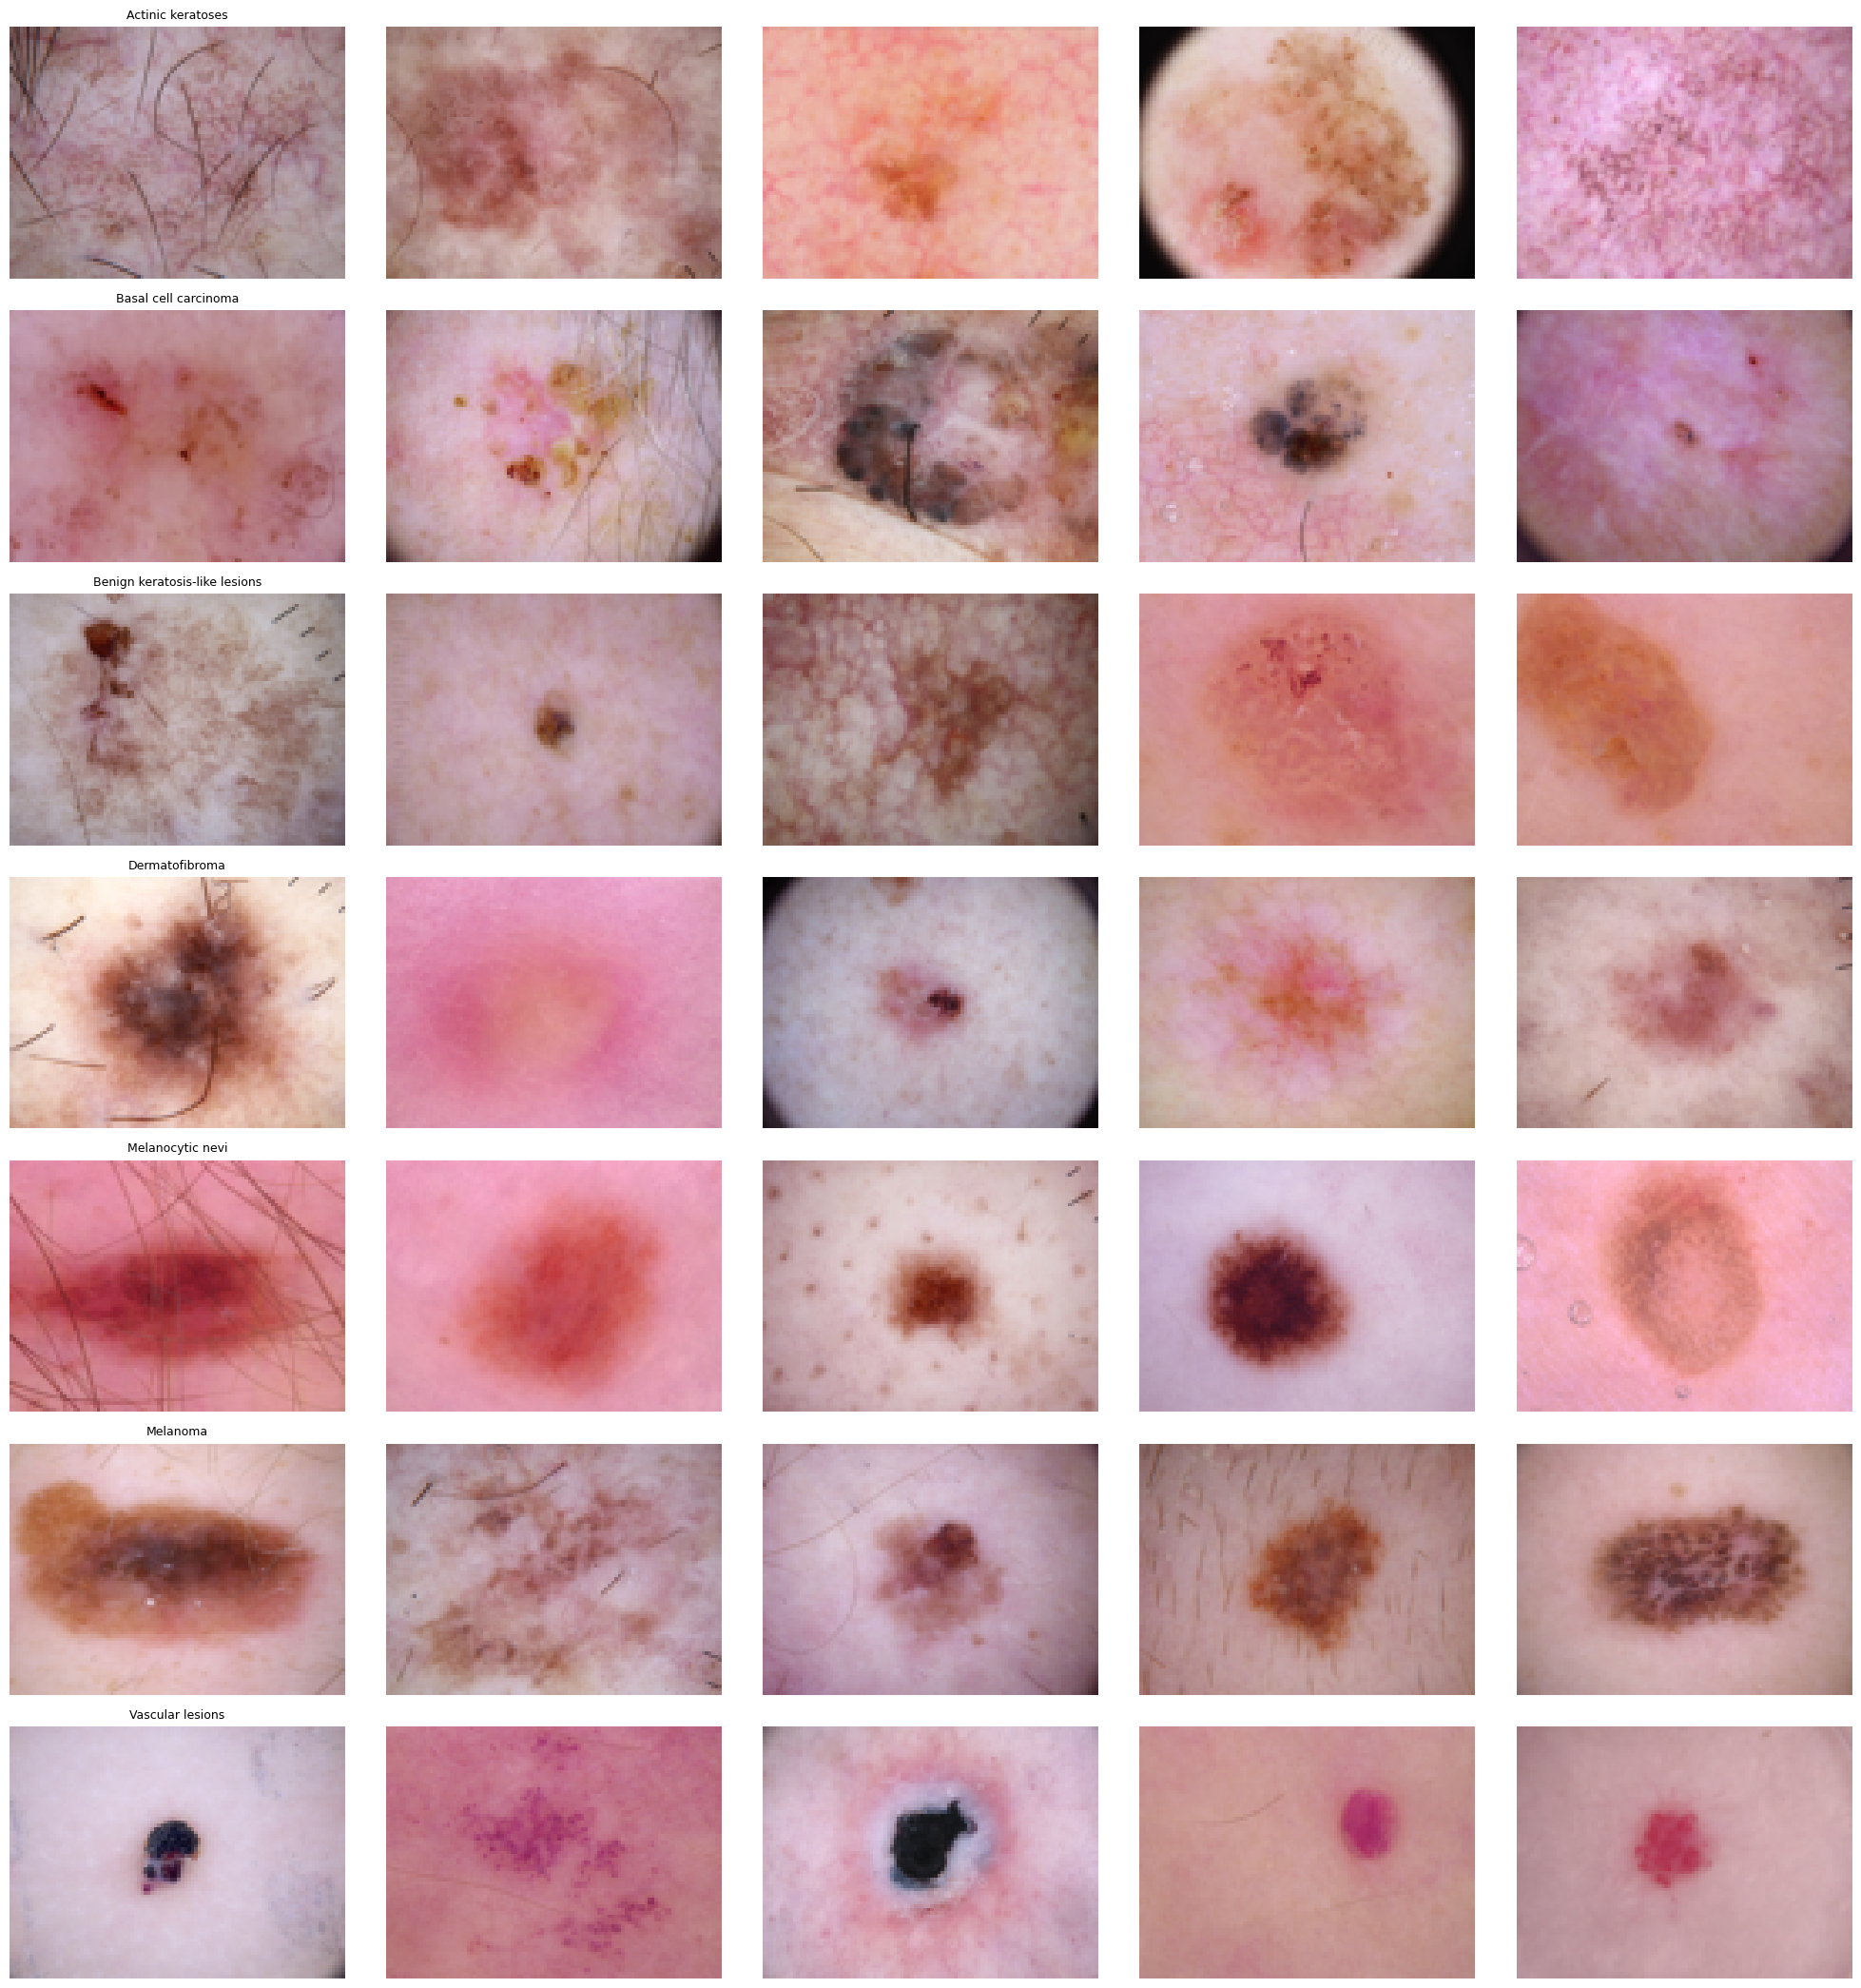

In [40]:
# Sample images per class
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize=(4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs,
                                          skin_df.sort_values('cell_type').groupby('cell_type')):
    n_axs[0].set_title(type_name, fontsize=9)
    sample = type_rows.sample(min(n_samples, len(type_rows)), random_state=42)
    for c_ax, (_, row) in zip(n_axs, sample.iterrows()):
        img = Image.open(row['path']).resize((100, 75))
        c_ax.imshow(img)
        c_ax.axis('off')
plt.tight_layout()
plt.savefig('Photos/category_samples.png', dpi=150)
plt.show()

### 5. Train / Validation / Test Split

In [41]:
labels = skin_df['cell_type_idx'].values
paths  = skin_df['path'].values

# 80 / 20 train-test, stratified
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    paths, labels, test_size=0.20, stratify=labels, random_state=SEED)

# 80 / 20 of train → 64 / 16 overall for train / val
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_train_paths, y_train, test_size=0.20, stratify=y_train, random_state=SEED)

print(f'Train: {len(X_train_paths)} | Val: {len(X_val_paths)} | Test: {len(X_test_paths)}')

Train: 4780 | Val: 1196 | Test: 1494


### 6. Improvement 4 — Domain-Safe Data Augmentation
Flips and rotation are clinically valid because skin lesions have no canonical orientation. Colour jitter simulates variation across imaging hardware.

In [42]:
# ImageNet mean/std used because ResNet18 weights come from ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),                # clinically valid
    transforms.RandomVerticalFlip(),                  # clinically valid
    transforms.RandomRotation(degrees=30),            # lesions have no canonical orientation
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.1                       # simulates imaging hardware variation
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### 7. Dataset Class

In [43]:
class SkinLesionDataset(Dataset):
    """Loads images on-the-fly from disk paths — avoids RAM explosion."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


train_dataset = SkinLesionDataset(X_train_paths, y_train, transform=train_transform)
val_dataset   = SkinLesionDataset(X_val_paths,   y_val,   transform=val_test_transform)
test_dataset  = SkinLesionDataset(X_test_paths,  y_test,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 150 | Val: 38 | Test: 47


### 8. Improvement 1 — Transfer Learning with ResNet18
ResNet18, pre-trained on ImageNet, provides rich feature representations learned on 1.2M images. We freeze early layers and only fine-tune the final classification head, then progressively unfreeze.

In [44]:
def build_resnet18(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    """
    Load ImageNet-pretrained ResNet18 and replace the final FC layer
    to output `num_classes` logits.
    
    Setting freeze_backbone=True trains only the new head first,
    which is standard practice to avoid destroying pretrained features.
    """
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC layer — this is always trainable
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model


model = build_resnet18(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Trainable params: 133,127 / 11,309,639 (1.2%)


### 9. Improvement 2 — Focal Loss
Focal Loss (Lin et al., 2017) down-weights easy, well-classified examples and forces the gradient to focus on hard, misclassified minority cases. This directly addresses the 6705 vs 115 class imbalance.

In [45]:
class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        gamma (float): focusing parameter. gamma=0 reduces to cross-entropy.
        alpha (Tensor | None): per-class weight vector of shape (num_classes,).
                               Pass None for uniform weights.
        reduction (str): 'mean' or 'sum'.
    """

    def __init__(self, gamma: float = 2.0,
                 alpha=None,
                 reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits: (N, C)   targets: (N,)
        log_probs = F.log_softmax(logits, dim=1)           # (N, C)
        probs     = torch.exp(log_probs)                   # (N, C)

        # Gather the probability of the correct class for each sample
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # (N,)
        pt     = probs.gather(1,     targets.unsqueeze(1)).squeeze(1)  # (N,)

        focal_weight = (1 - pt) ** self.gamma             # (N,)
        loss = -focal_weight * log_pt                     # (N,)

        if self.alpha is not None:
            alpha_t = self.alpha[targets]                 # (N,)
            loss    = alpha_t * loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()


criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)
print(f'Loss function: FocalLoss (gamma={FOCAL_GAMMA})')

Loss function: FocalLoss (gamma=2.0)


### 10. Optimizer & Scheduler

In [46]:
# Phase 1: Only train the new classification head
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

# Reduce LR when validation accuracy plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, min_lr=1e-6
)

print('Optimizer: Adam | Scheduler: ReduceLROnPlateau')

Optimizer: Adam | Scheduler: ReduceLROnPlateau


### 11. Training Loop

In [47]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    """Single epoch train (optimizer provided) or eval (optimizer=None)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


if __name__ == '__main__':
    
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc  = 0.0
    UNFREEZE_EPOCH = 5   # unfreeze backbone after this many warm-up epochs
    
    print(f'Training for {EPOCHS} epochs on {DEVICE}\n')
    start_time = time.time()
    
    for epoch in range(1, EPOCHS + 1):
    
        # ── Progressive unfreezing ─────────────────────────────────────────────
        if epoch == UNFREEZE_EPOCH + 1:
            print(f'\n[Epoch {epoch}] Unfreezing backbone — fine-tuning entire network.')
            for param in model.parameters():
                param.requires_grad = True
            # Lower LR for backbone to avoid catastrophic forgetting
            optimizer = torch.optim.Adam([
                {'params': list(model.children())[:-1][0].parameters(), 'lr': LR * 0.1},
                {'params': model.fc.parameters(),                        'lr': LR}
            ])
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', patience=3, factor=0.5, min_lr=1e-7
            )
    
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)
        scheduler.step(val_acc)
    
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
    
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_SAVE)
            tag = '  ← best'
        else:
            tag = ''
    
        print(f'Epoch {epoch:2d}/{EPOCHS}  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%{tag}')
    
    elapsed = time.time() - start_time
    print(f'\nTraining complete in {elapsed/60:.1f} min. Best val acc: {best_val_acc*100:.2f}%')

Training for 30 epochs on cpu

Epoch  1/30  Train Loss: 0.6467  Train Acc: 70.56%  Val Loss: 0.5063  Val Acc: 73.75%  ← best
Epoch  2/30  Train Loss: 0.5129  Train Acc: 73.60%  Val Loss: 0.4663  Val Acc: 75.42%  ← best
Epoch  3/30  Train Loss: 0.4736  Train Acc: 74.23%  Val Loss: 0.4431  Val Acc: 75.25%
Epoch  4/30  Train Loss: 0.4607  Train Acc: 74.64%  Val Loss: 0.4231  Val Acc: 76.92%  ← best
Epoch  5/30  Train Loss: 0.4459  Train Acc: 74.94%  Val Loss: 0.4132  Val Acc: 76.67%

[Epoch 6] Unfreezing backbone — fine-tuning entire network.
Epoch  6/30  Train Loss: 0.4345  Train Acc: 75.25%  Val Loss: 0.3920  Val Acc: 77.42%  ← best
Epoch  7/30  Train Loss: 0.4229  Train Acc: 75.50%  Val Loss: 0.3891  Val Acc: 77.34%
Epoch  8/30  Train Loss: 0.4040  Train Acc: 76.28%  Val Loss: 0.3735  Val Acc: 77.59%  ← best
Epoch  9/30  Train Loss: 0.3968  Train Acc: 75.84%  Val Loss: 0.3760  Val Acc: 76.59%
Epoch 10/30  Train Loss: 0.3933  Train Acc: 76.26%  Val Loss: 0.3644  Val Acc: 77.51%
Epoch 11

### 12. Training History Plot

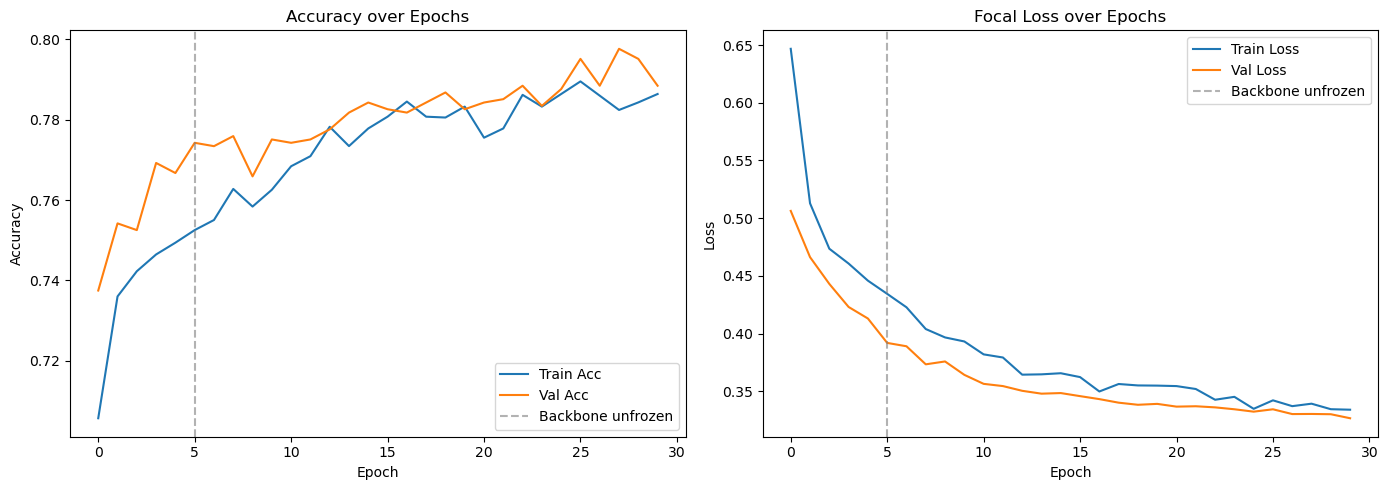

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history['train_acc'], label='Train Acc')
axes[0].plot(history['val_acc'],   label='Val Acc')
axes[0].axvline(UNFREEZE_EPOCH, color='grey', linestyle='--', alpha=0.6, label='Backbone unfrozen')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history['train_loss'], label='Train Loss')
axes[1].plot(history['val_loss'],   label='Val Loss')
axes[1].axvline(UNFREEZE_EPOCH, color='grey', linestyle='--', alpha=0.6, label='Backbone unfrozen')
axes[1].set_title('Focal Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('Photos/training_history.png', dpi=150)
plt.show()

### 13. Load Best Model & Evaluate on Test Set

In [49]:
# Load the checkpoint with the best validation accuracy
model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

overall_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {overall_acc*100:.2f}%')

Test Accuracy: 78.31%


### 14. Improvement 3 — Per-Class Metrics: Recall & AUC
Overall accuracy hides poor minority-class performance. Per-class recall shows how many true melanoma cases were correctly caught — the most clinically critical metric.

In [50]:
print('=' * 60)
print('Classification Report (per-class Precision / Recall / F1)')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Per-class AUC (one-vs-rest)
try:
    auc_scores = roc_auc_score(
        all_labels, all_probs,
        multi_class='ovr', average=None
    )
    print('\nPer-Class AUC (One-vs-Rest):')
    for cls, auc in zip(CLASS_NAMES, auc_scores):
        print(f'  {cls:8s}: {auc:.4f}')
    print(f'\n  Macro-avg AUC: {auc_scores.mean():.4f}')
except Exception as e:
    print(f'AUC computation skipped: {e}')

Classification Report (per-class Precision / Recall / F1)
              precision    recall  f1-score   support

       akiec       0.46      0.13      0.20        46
         bcc       0.48      0.48      0.48        65
         bkl       0.45      0.39      0.42       145
          df       0.00      0.00      0.00        15
          nv       0.86      0.95      0.90      1080
         mel       0.47      0.33      0.39       123
        vasc       0.80      0.20      0.32        20

    accuracy                           0.78      1494
   macro avg       0.50      0.36      0.39      1494
weighted avg       0.75      0.78      0.76      1494


Per-Class AUC (One-vs-Rest):
  akiec   : 0.8975
  bcc     : 0.9355
  bkl     : 0.8848
  df      : 0.8764
  nv      : 0.9255
  mel     : 0.8734
  vasc    : 0.9619

  Macro-avg AUC: 0.9078


### 15. Confusion Matrix

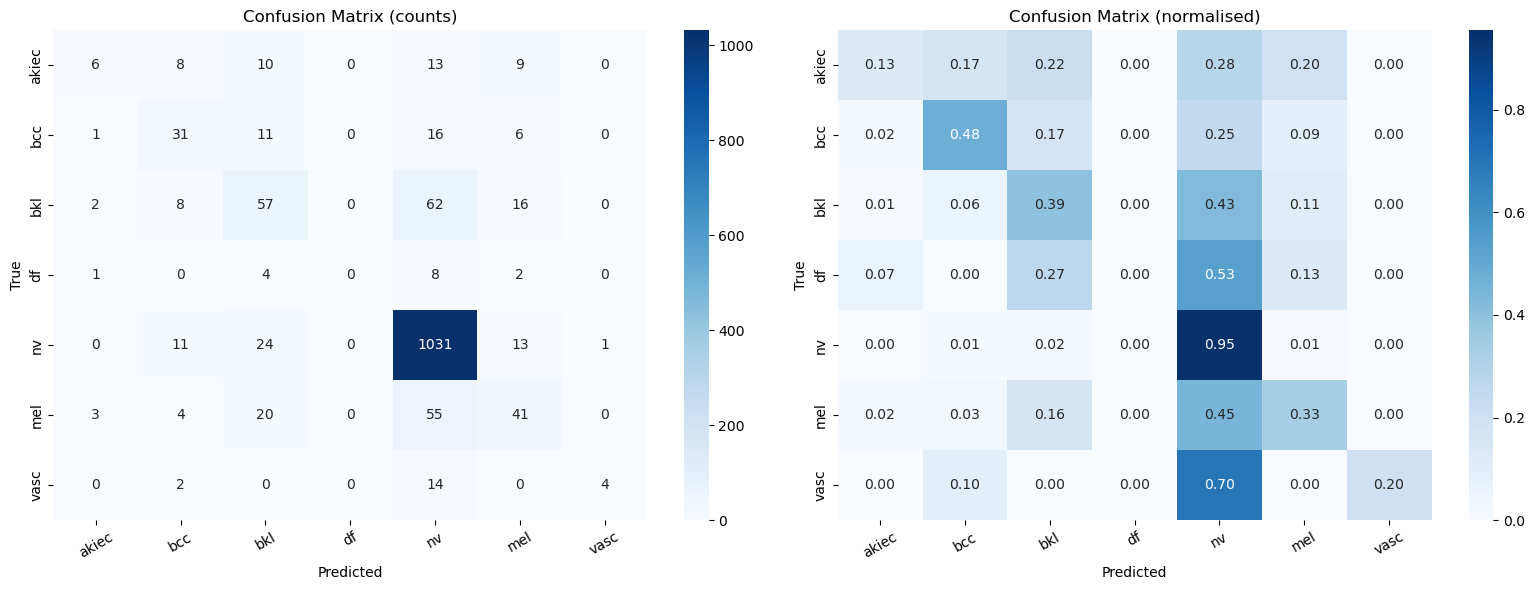

In [51]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('Photos/confusion_matrix.png', dpi=150)
plt.show()

### 16. Improvement 3 — Grad-CAM Visualisation
Grad-CAM (Gradient-weighted Class Activation Mapping) produces heatmaps highlighting which regions of the image most influenced each classification decision — making predictions interpretable for clinicians.

In [52]:
class GradCAM:
    """
    Post-hoc Grad-CAM for any CNN.
    Attaches hooks to `target_layer` and computes the gradient-weighted
    activation map during a forward pass.
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor: torch.Tensor, class_idx: int = None) -> np.ndarray:
        """
        Returns a heatmap of shape (H, W) normalised to [0, 1].
        If class_idx is None, uses the predicted class.
        """
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)  # (1, C, H, W)
        input_tensor.requires_grad_(True)

        logits = self.model(input_tensor)                     # forward
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad()
        logits[0, class_idx].backward()                      # backward

        # Global-average-pool the gradients over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam     = (weights * self.activations).sum(dim=1).squeeze()  # (H, W)
        cam     = F.relu(cam)

        cam = cam.cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# Attach Grad-CAM to the last convolutional block of ResNet18
grad_cam = GradCAM(model, target_layer=model.layer4[-1])
print('Grad-CAM attached to model.layer4[-1]')

Grad-CAM attached to model.layer4[-1]


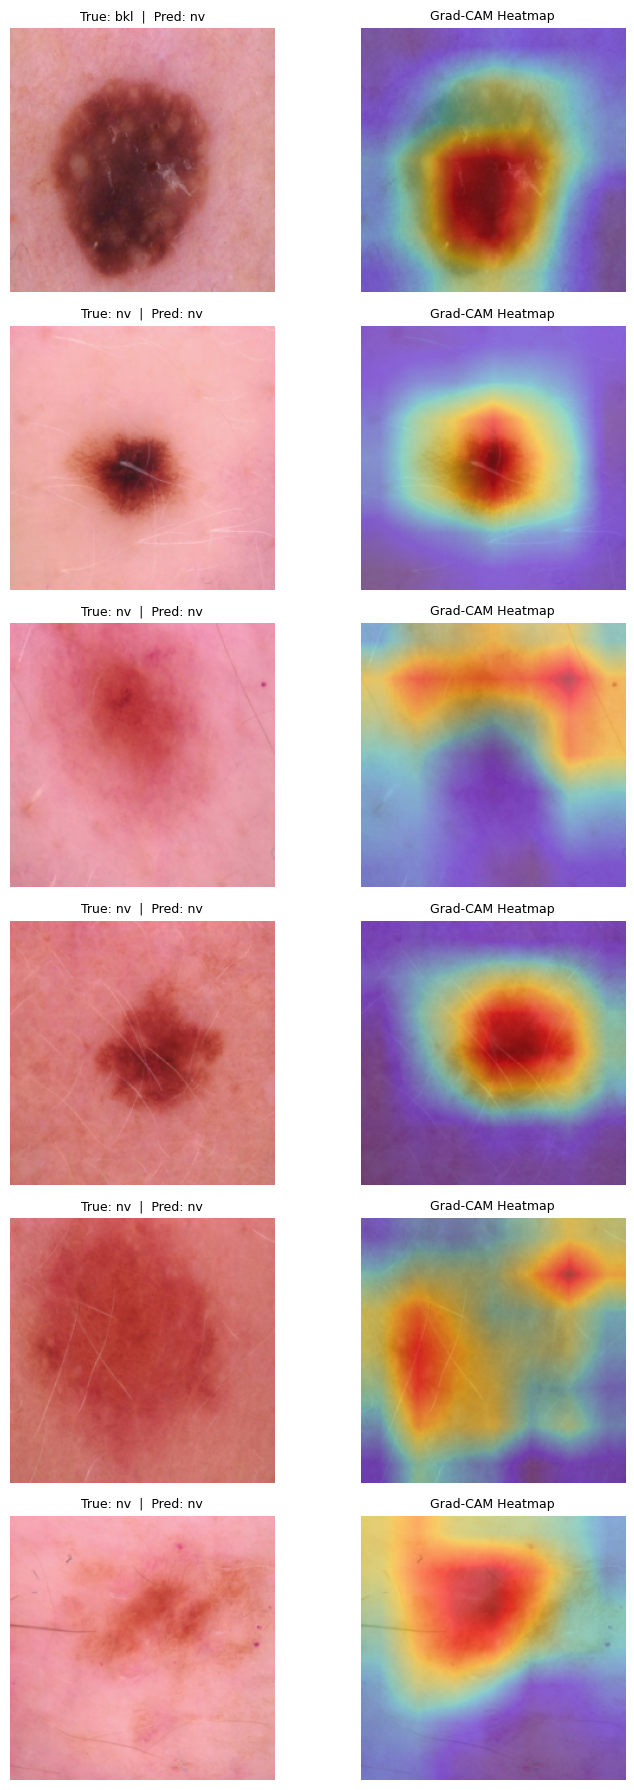

Grad-CAM figure saved to Photos/gradcam.png


In [53]:
def show_gradcam(dataset, grad_cam, num_images: int = 6,
                 class_names=CLASS_NAMES, save_path='Photos/gradcam.png'):
    """
    Draw original image alongside Grad-CAM heatmap overlay
    for a random selection of test images.
    """
    indices = np.random.choice(len(dataset), num_images, replace=False)
    fig, axes = plt.subplots(num_images, 2, figsize=(8, 3 * num_images))

    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]

        cam, pred_idx = grad_cam.generate(img_tensor)

        # De-normalise for display
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        img_disp = (img_tensor * std + mean).permute(1, 2, 0).numpy()
        img_disp = np.clip(img_disp, 0, 1)

        # Resize CAM to image size
        cam_resized = np.array(
            Image.fromarray((cam * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR
            )
        ) / 255.0

        axes[row, 0].imshow(img_disp)
        axes[row, 0].set_title(
            f'True: {class_names[true_label.item()]}  |  Pred: {class_names[pred_idx]}',
            fontsize=9
        )
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img_disp)
        axes[row, 1].imshow(cam_resized, cmap='jet', alpha=0.45)
        axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Grad-CAM figure saved to {save_path}')


show_gradcam(test_dataset, grad_cam, num_images=6)

### 17. Per-Class Recall Bar Chart

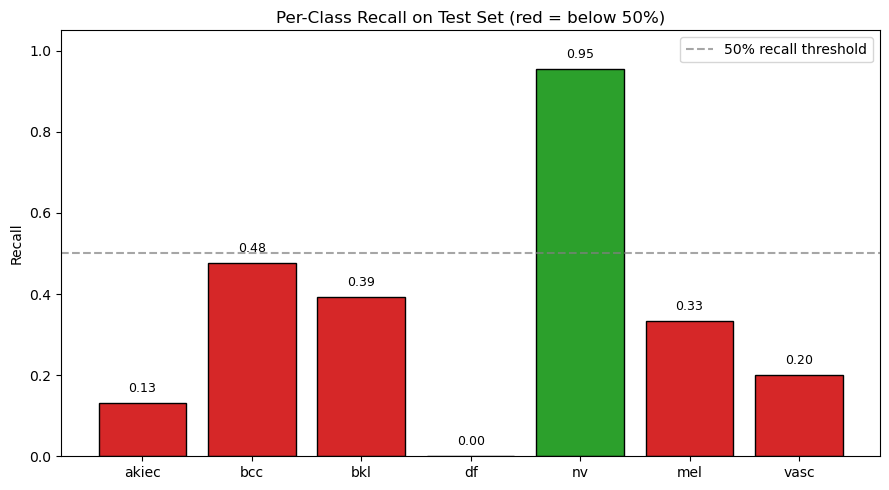

In [54]:
per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if r < 0.5 else '#2ca02c' for r in per_class_recall]
bars = ax.bar(CLASS_NAMES, per_class_recall, color=colors, edgecolor='black')
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.7, label='50% recall threshold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Recall')
ax.set_title('Per-Class Recall on Test Set (red = below 50%)')
ax.legend()
for bar, val in zip(bars, per_class_recall):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('Photos/per_class_recall.png', dpi=150)
plt.show()

### 18. Summary

In [55]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'Model          : ResNet18 (Transfer Learning)')
print(f'Loss           : Focal Loss (gamma={FOCAL_GAMMA})')
print(f'Augmentation   : Flip + Rotation + ColorJitter')
print(f'Explainability : Grad-CAM + Per-class Recall + AUC')
print(f'Test Accuracy  : {overall_acc*100:.2f}%')
print()
print('Per-Class Recall:')
for cls, rec in zip(CLASS_NAMES, per_class_recall):
    print(f'  {cls:8s}: {rec:.4f}')
try:
    print(f'\nMacro AUC: {auc_scores.mean():.4f}')
except:
    pass

FINAL RESULTS SUMMARY
Model          : ResNet18 (Transfer Learning)
Loss           : Focal Loss (gamma=2.0)
Augmentation   : Flip + Rotation + ColorJitter
Explainability : Grad-CAM + Per-class Recall + AUC
Test Accuracy  : 78.31%

Per-Class Recall:
  akiec   : 0.1304
  bcc     : 0.4769
  bkl     : 0.3931
  df      : 0.0000
  nv      : 0.9546
  mel     : 0.3333
  vasc    : 0.2000

Macro AUC: 0.9078
